# Loan Approval Prediction System

This project predicts whether a loan applicant is likely to default or repay based on financial and personal details.

## Objective:

To build a machine learning model that helps banks reduce financial risk by identifying high-risk applicants.

## Approach:

* Data preprocessing (handling categorical features)
* Model training (Logistic Regression, Decision Tree, Random Forest)
* Model comparison
* Final prediction on unseen data


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

#1.Importing Dataset

In [8]:
train_df=pd.read_csv('/content/drive/MyDrive/loan_approval/train.csv')
test_df=pd.read_csv('/content/drive/MyDrive/loan_approval/test.csv')

print(train_df.head())


   id  person_age  person_income person_home_ownership  person_emp_length  \
0   0          37          35000                  RENT                0.0   
1   1          22          56000                   OWN                6.0   
2   2          29          28800                   OWN                8.0   
3   3          30          70000                  RENT               14.0   
4   4          22          60000                  RENT                2.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_percent_income  \
0   EDUCATION          B       6000          11.49                 0.17   
1     MEDICAL          C       4000          13.35                 0.07   
2    PERSONAL          A       6000           8.90                 0.21   
3     VENTURE          B      12000          11.11                 0.17   
4     MEDICAL          A       6000           6.92                 0.10   

  cb_person_default_on_file  cb_person_cred_hist_length  loan_status  
0              

In [9]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [10]:
print(train_df.isnull().sum())

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64


#2.EDA

##EDA: Plot 1 - Numeric Feature Distributions

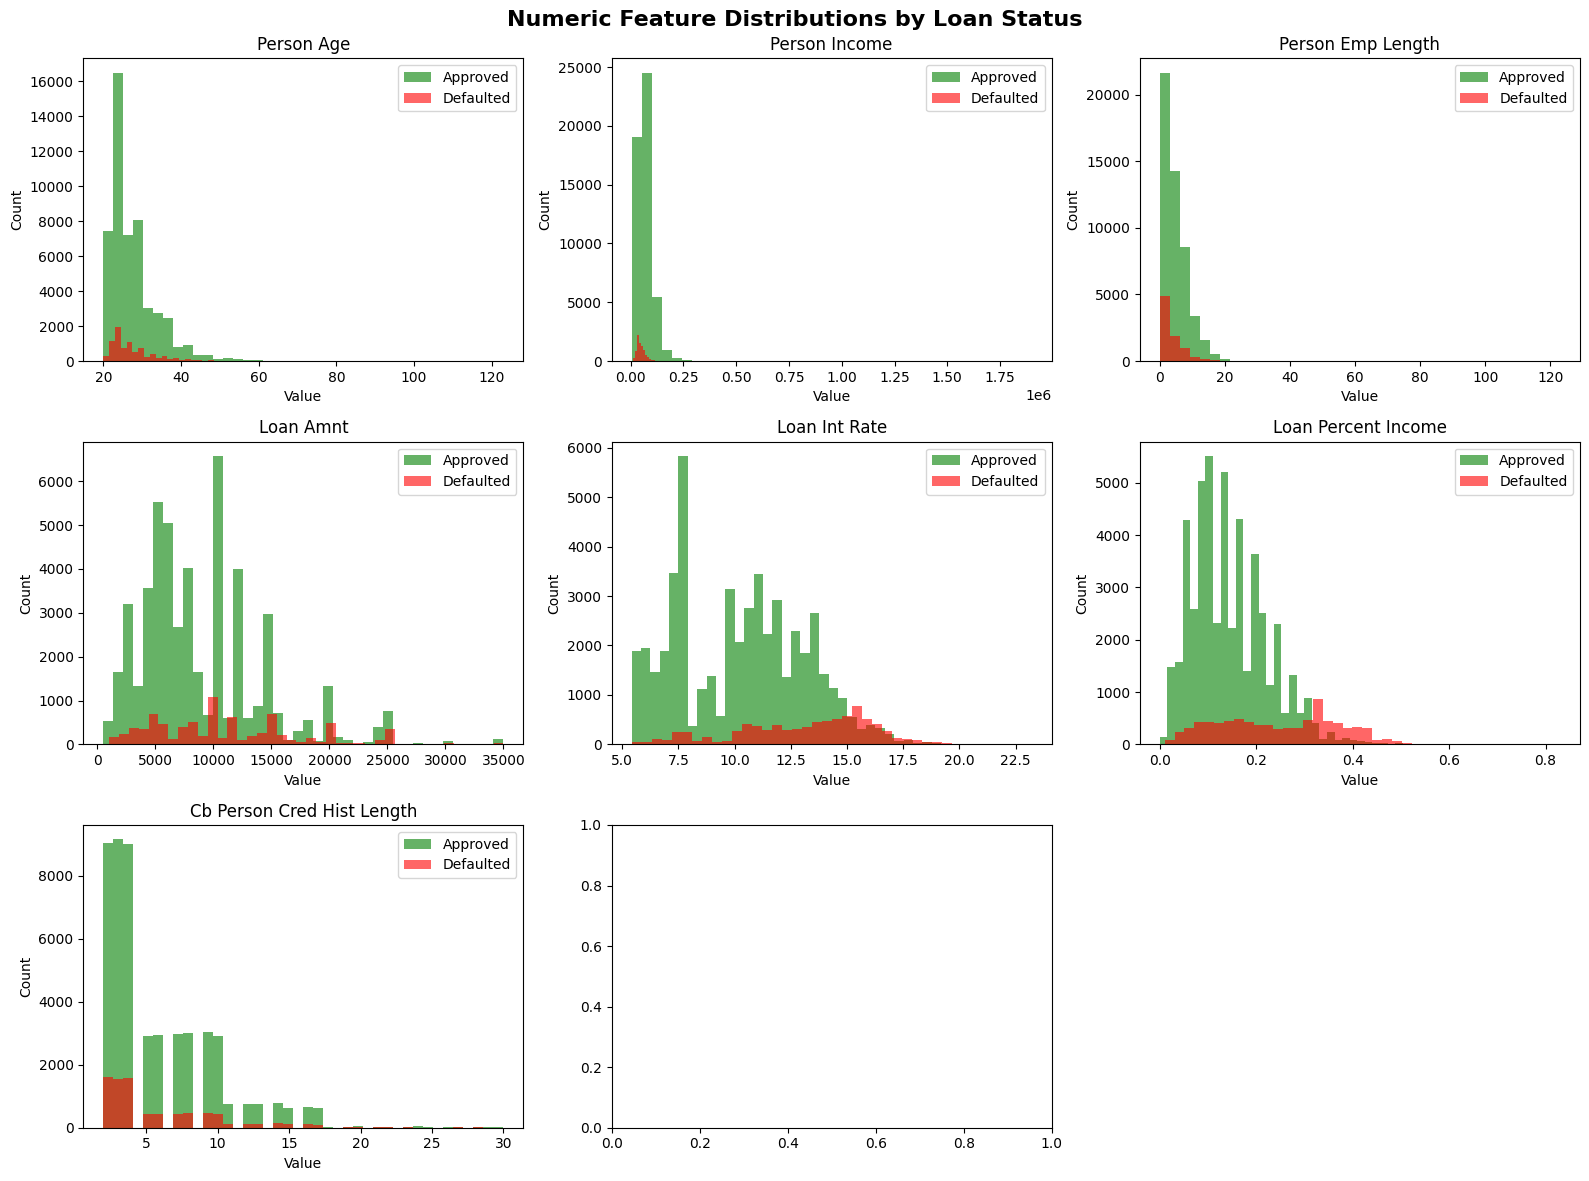

In [30]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Numeric Feature Distributions by Loan Status', fontsize=16, fontweight='bold')

for ax, col in zip(axes.flat, numeric_cols):
    for status, color, label in [(0, 'green', 'Approved'), (1, 'red', 'Defaulted')]:
        subset = train_df[train_df['loan_status'] == status][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=label)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()

# hide the empty 9th subplot
axes[2][2].axis('off')

plt.tight_layout()
plt.show()

##EDA: Plot 2 - Categorical Features

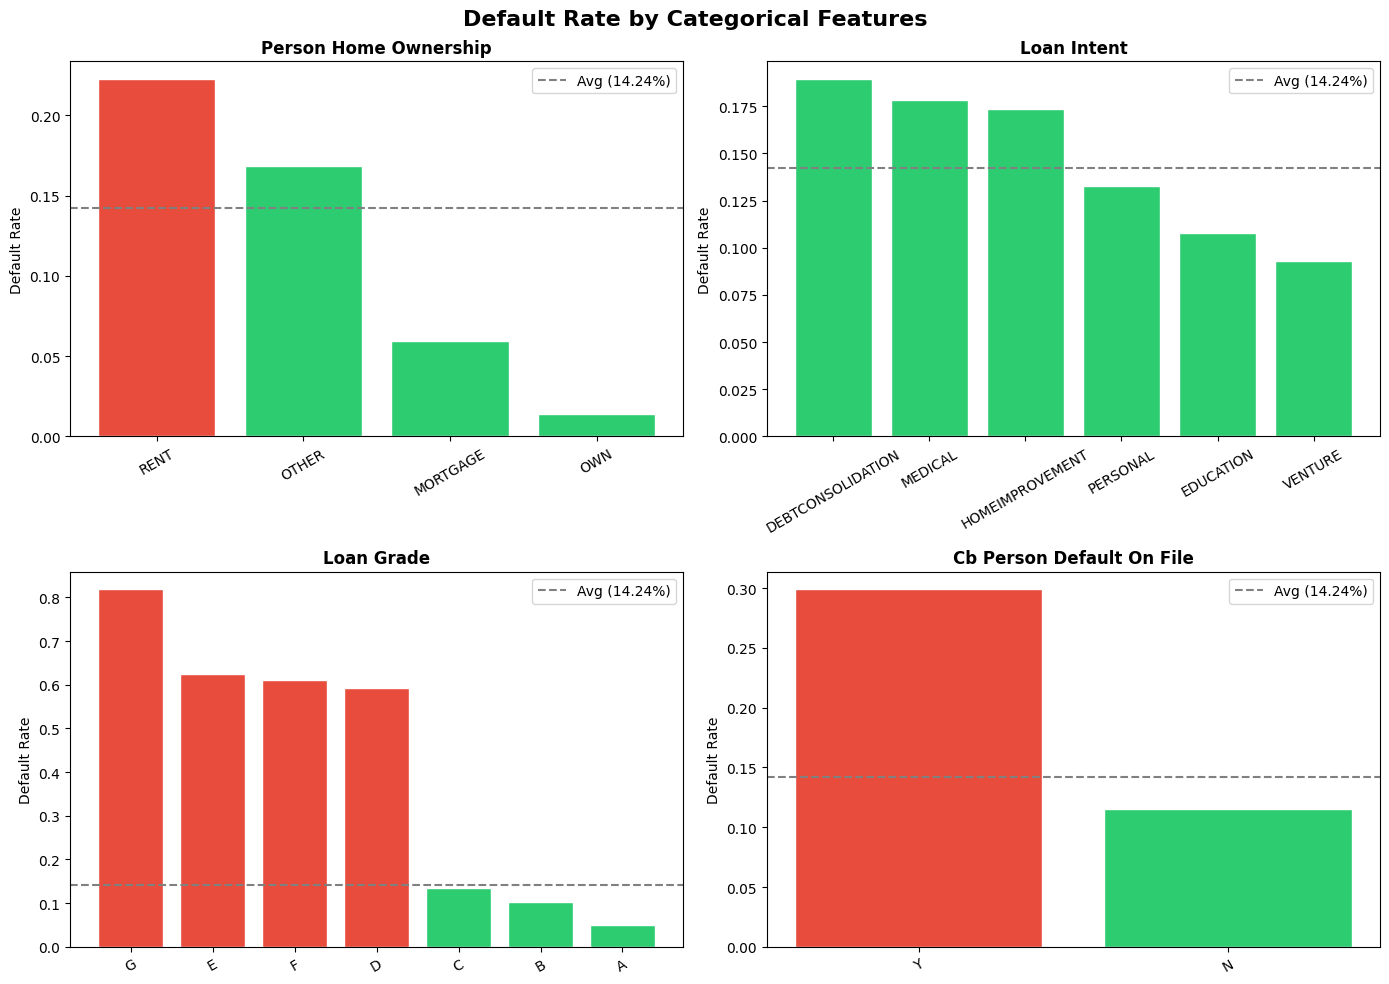

In [31]:
cat_cols = ['person_home_ownership', 'loan_intent',
            'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Default Rate by Categorical Features', fontsize=16, fontweight='bold')

for ax, col in zip(axes.flat, cat_cols):
    default_rate = train_df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    bars = ax.bar(default_rate.index, default_rate.values,
                  color=['#e74c3c' if v > 0.2 else '#2ecc71' for v in default_rate.values],
                  edgecolor='white')
    ax.axhline(train_df['loan_status'].mean(), linestyle='--',
               color='gray', label=f'Avg ({train_df["loan_status"].mean():.2%})')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Default Rate')
    ax.tick_params(axis='x', rotation=30)
    ax.legend()

plt.tight_layout()
plt.show()

##EDA: Plot 3 - Correlation Heatmap

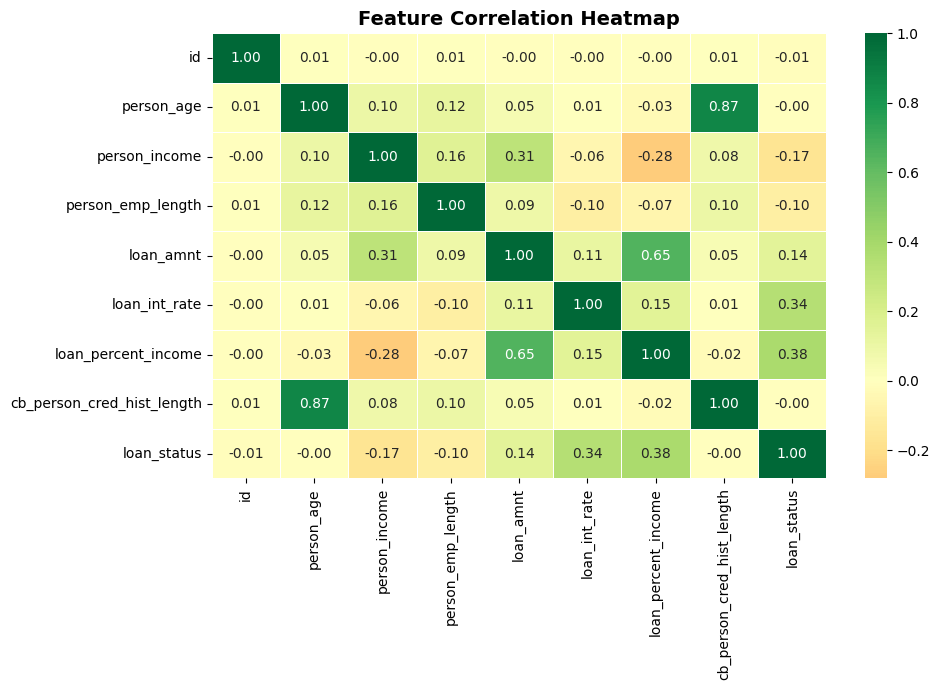

In [32]:

plt.figure(figsize=(10, 7))

# only numeric columns
numeric_df = train_df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(),
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#2.Making the data ready for model training

Splitting the data

In [11]:
from sklearn.model_selection import train_test_split

X = train_df.drop("loan_status", axis=1)
y = train_df["loan_status"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_val.shape)

(46916, 12) (11729, 12)


### Encoding

Categorical features were converted into numerical values using Label Encoding to make them suitable for machine learning models.


In [12]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

for col in categorical_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col])
    X_val[col] = le.transform(X_val[col])

    encoders[col] = le

In [13]:
for col in categorical_cols:
    print(f"{col}:")
    print(dict(zip(encoders[col].classes_, encoders[col].transform(encoders[col].classes_))))
    print()

person_home_ownership:
{'MORTGAGE': np.int64(0), 'OTHER': np.int64(1), 'OWN': np.int64(2), 'RENT': np.int64(3)}

loan_intent:
{'DEBTCONSOLIDATION': np.int64(0), 'EDUCATION': np.int64(1), 'HOMEIMPROVEMENT': np.int64(2), 'MEDICAL': np.int64(3), 'PERSONAL': np.int64(4), 'VENTURE': np.int64(5)}

loan_grade:
{'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'E': np.int64(4), 'F': np.int64(5), 'G': np.int64(6)}

cb_person_default_on_file:
{'N': np.int64(0), 'Y': np.int64(1)}



#3.Model training with train data

1.Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nReport:\n", classification_report(y_val, y_pred))


Accuracy: 0.8932560320572939

Confusion Matrix:
 [[9849  238]
 [1014  628]]

Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94     10087
           1       0.73      0.38      0.50      1642

    accuracy                           0.89     11729
   macro avg       0.82      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729



In [15]:
print(y.value_counts())

loan_status
0    50295
1     8350
Name: count, dtype: int64


The dataset is imbalanced, with more non-default cases than default cases.
To handle this, class_weight='balanced' was used in models.

In [16]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nReport:\n", classification_report(y_val, y_pred))

Accuracy: 0.7709097109728025

Confusion Matrix:
 [[7674 2413]
 [ 274 1368]]

Report:
               precision    recall  f1-score   support

           0       0.97      0.76      0.85     10087
           1       0.36      0.83      0.50      1642

    accuracy                           0.77     11729
   macro avg       0.66      0.80      0.68     11729
weighted avg       0.88      0.77      0.80     11729



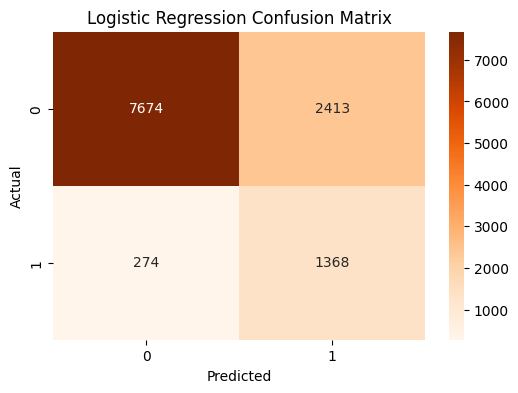

In [17]:

cm_lr = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

2.Decision Tree

In [18]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred_dt))
print("\nReport:\n", classification_report(y_val, y_pred_dt))

Accuracy: 0.9163611561087902

Confusion Matrix:
 [[9575  512]
 [ 469 1173]]

Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95     10087
           1       0.70      0.71      0.71      1642

    accuracy                           0.92     11729
   macro avg       0.82      0.83      0.83     11729
weighted avg       0.92      0.92      0.92     11729



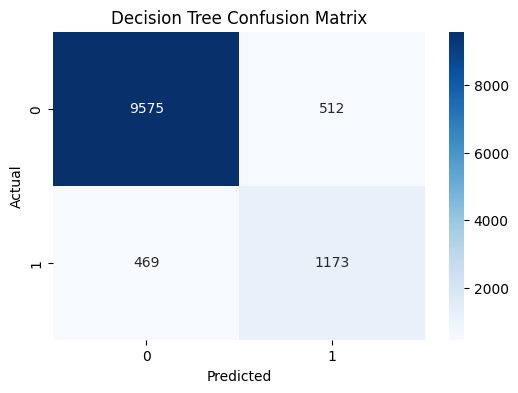

In [19]:
cm_dt = confusion_matrix(y_val, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

3.Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred_rf))
print("\nReport:\n", classification_report(y_val, y_pred_rf))

Accuracy: 0.9495268138801262

Confusion Matrix:
 [[9996   91]
 [ 501 1141]]

Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97     10087
           1       0.93      0.69      0.79      1642

    accuracy                           0.95     11729
   macro avg       0.94      0.84      0.88     11729
weighted avg       0.95      0.95      0.95     11729



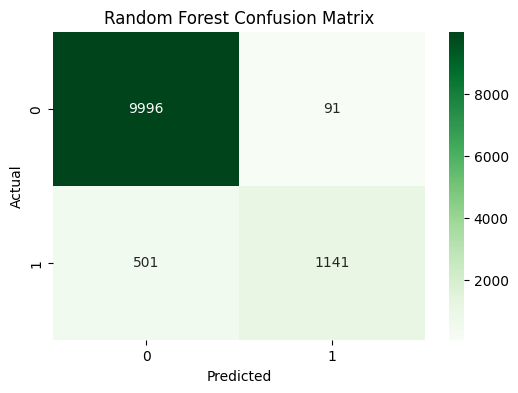

In [21]:
cm_rf = confusion_matrix(y_val, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Identifying which features influence loan approval decisions

In [22]:
importance = rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(importance_df)

                       Feature  Importance
9          loan_percent_income    0.210654
6                   loan_grade    0.146926
8                loan_int_rate    0.145796
2                person_income    0.130325
0                           id    0.066384
7                    loan_amnt    0.066015
3        person_home_ownership    0.059540
5                  loan_intent    0.047015
4            person_emp_length    0.043627
1                   person_age    0.038817
11  cb_person_cred_hist_length    0.032339
10   cb_person_default_on_file    0.012562


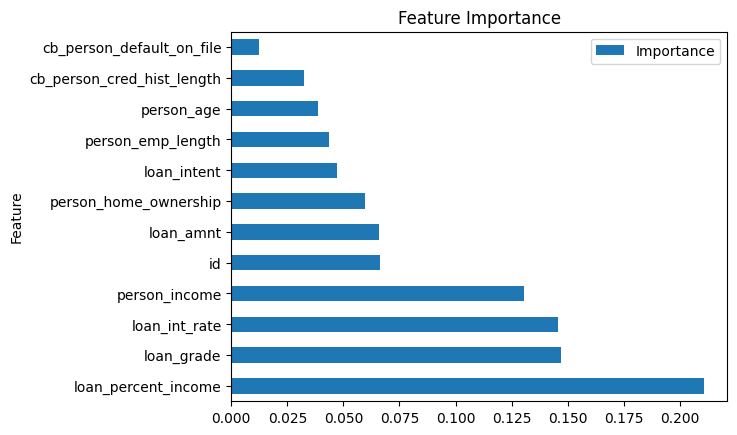

In [23]:


importance_df.plot(kind='barh', x='Feature', y='Importance')
plt.title("Feature Importance")
plt.show()

Selecting the best Model

In [24]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic", "Logistic Balanced", "Decision Tree", "Random Forest"],
    "Accuracy": [0.89, 0.77, 0.91, 0.95],
    "Recall (Risk)": [0.38, 0.83, 0.71, 0.69]
})

print(comparison)

               Model  Accuracy  Recall (Risk)
0           Logistic      0.89           0.38
1  Logistic Balanced      0.77           0.83
2      Decision Tree      0.91           0.71
3      Random Forest      0.95           0.69


#4.Using Test data
Trained rf used to predict loan outcome on unseen test data



In [25]:
for col in categorical_cols:
    test_df[col] = encoders[col].transform(test_df[col])

In [26]:
test_predictions = rf_model.predict(test_df)

In [27]:
submission = pd.DataFrame({
    "loan_status": test_predictions
})

submission.to_csv("loan_predictions.csv", index=False)

Example

In [28]:
sample = X_val.iloc[0]
print(sample)
print("Prediction:", rf_model.predict([sample]))

id                             4657.00
person_age                       23.00
person_income                 40000.00
person_home_ownership             3.00
person_emp_length                 0.00
loan_intent                       3.00
loan_grade                        0.00
loan_amnt                      3700.00
loan_int_rate                     8.00
loan_percent_income               0.09
cb_person_default_on_file         0.00
cb_person_cred_hist_length        4.00
Name: 4657, dtype: float64
Prediction: [0]


The model prioritizes reducing false approvals (risky loans being approved), which is critical in banking systems.

## Conclusion

Random Forest achieved the best performance with 95% accuracy and balanced risk detection.

The model effectively identifies high-risk applicants while minimizing false approvals, making it suitable for real-world financial decision-making.

### Key Insight:

Credit history, loan amount, and income are the most influential factors.


## Limitations

* Model depends on historical data
* May not generalize to all real-world cases
* Some external factors are not included


## Future Scope

* Use advanced models like XGBoost
* Deploy as a web application
* Add explainable AI techniques
